In [ ]:
import random
import networkx as nx
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from hcgcr_gather_data import hcgcr_data
from cup_main import color_update_propagation
from cup_functions import update_queue_cup, update_queue_cas, update_queue_cor
from hcgcr import hcgcr

sns.set_theme(style="whitegrid")
update_functions = [update_queue_cup, update_queue_cas, update_queue_cor]



In [2]:
# python checks
log_pi_table = np.load("log_pi_table.npy")
a = np.array([1,1,5,1])
print(log_pi_table[0:10])
print(log_pi_table[a])

[     -inf 0.6931472 1.0986123 1.6094379 1.9459101 2.3978953 2.5649494
 2.8332133 2.944439  3.1354942]
[0.6931472 0.6931472 2.3978953 0.6931472]


queue_update_function is one of the following: [update_queue_add_all_neighbors, update_queue_remove_asymmetric, update_queue_remove_unchanged_orbits]

In [2]:
def is_coloring_correct(G, c_test):
    c_correct = hcgcr(G)
    c, _ = pd.factorize(c_test)
    c_test_recolored = pd.Series(c + 1, index=c_correct.index)
    return c_test_recolored.equals(c_correct)

def add_random_edge(G):
    non_edges = list(nx.non_edges(G))
    if not non_edges:  # Check if there are no available edges
        print("No non-edges available to add.")
        return False, False
    G_new = G.copy()
    new_edge = random.choice(non_edges)
    G_new.add_edge(new_edge[0], new_edge[1])
    return G_new, new_edge

# testing based on binomial random graphs
def random_testing_correctness(test_size, test_min_n, test_max_n, p):
    i = 0
    correct_nr = 0
    incorrect_list = [[], [], []]
    while i < test_size:
        print("Iteration ", i)
        n1 = random.randint(test_min_n, test_max_n)
        G1 = nx.fast_gnp_random_graph(n1,p)
        
        G2, new_edge = add_random_edge(G1)
        iterations = hcgcr_data(G1)
        j = 0
        correct = True
        for queue_update_function in update_functions:
            iterations_up_list = color_update_propagation(G2, new_edge, iterations, queue_update_function)
            c_updated = iterations_up_list[-1]
            is_correct = is_coloring_correct(G2, c_updated)
            if is_correct != True:
                print("Incorrect coloring found in iteration ", i, " with update function ", queue_update_function.__name__)
                correct = False
                incorrect_list[j].append([G1, new_edge])
            j += 1
        if correct == True:
            correct_nr += 1
        i += 1
    results = [correct_nr, incorrect_list]
    return results

In [6]:
test_size, test_min_n, test_max_n, p = 100, 100, 500, 0.05
results = random_testing_correctness(test_size, test_min_n, test_max_n, p)
results


Iteration  0
Iteration  1
Iteration  2
Iteration  3
Iteration  4
Iteration  5
Iteration  6
Iteration  7
Iteration  8
Iteration  9
Iteration  10
Iteration  11
Iteration  12
Iteration  13
Iteration  14
Iteration  15
Iteration  16
Iteration  17
Iteration  18
Iteration  19
Iteration  20
Iteration  21
Iteration  22
Iteration  23
Iteration  24
Iteration  25
Iteration  26
Iteration  27
Iteration  28
Iteration  29
Iteration  30
Iteration  31
Iteration  32
Iteration  33
Iteration  34
Iteration  35
Iteration  36
Iteration  37
Iteration  38
Iteration  39
Iteration  40
Iteration  41
Iteration  42
Iteration  43
Iteration  44
Iteration  45
Iteration  46
Iteration  47
Iteration  48
Iteration  49
Iteration  50
Iteration  51
Iteration  52
Iteration  53
Iteration  54
Iteration  55
Iteration  56
Iteration  57
Iteration  58
Iteration  59
Iteration  60
Iteration  61
Iteration  62
Iteration  63
Iteration  64
Iteration  65
Iteration  66
Iteration  67
Iteration  68
Iteration  69
Iteration  70
Iteration  71
It

[100, [[], [], []]]

In [10]:
# Disturbe the graph with a function used in the experiment
def generate_perturbed_graph(G, p, seed=None):
    rng = random.Random(seed)
    Gp = G.copy()

    m = G.number_of_edges()
    k = max(1, int(p * m))  # number of edits
    k_del = k // 2
    k_add = k - k_del

    # --- Delete edges ---
    edges = list(Gp.edges())
    del_edges = []
    if k_del > 0:
        del_edges = rng.sample(edges, min(k_del, len(edges)))
        Gp.remove_edges_from(del_edges)

    # --- Add edges ---
    # Candidate non-edges
    non_edges = list(nx.non_edges(Gp))
    add_edges = []
    if k_add > 0 and non_edges:
        add_edges = rng.sample(non_edges, min(k_add, len(non_edges)))
        Gp.add_edges_from(add_edges)

    return Gp, (add_edges + del_edges)

def random_testing_correctness_multiple_edges(test_size, test_min_n, test_max_n, p, a):
    i = 0
    correct_nr = 0
    incorrect_list = [[], [], []]
    while i < test_size:
        print("Iteration ", i)
        n1 = random.randint(test_min_n, test_max_n)
        G1 = nx.fast_gnp_random_graph(n1,p)
        
        G2, changed_edges = generate_perturbed_graph(G1, a)
        S = {v for e in changed_edges for v in e}
        iterations = hcgcr_data(G1)
        j = 0
        correct = True
        for queue_update_function in update_functions:
            iterations_up_list = color_update_propagation(G2, S, iterations, queue_update_function)
            c_updated = iterations_up_list[-1]
            is_correct = is_coloring_correct(G2, c_updated)
            if is_correct != True:
                print("Incorrect coloring found in iteration ", i, " with update function ", queue_update_function.__name__)
                correct = False
                incorrect_list[j].append([G1, S])
            j += 1
        if correct == True:
            correct_nr += 1
        i += 1
    results = [correct_nr, incorrect_list]
    return results

In [12]:
test_size, test_min_n, test_max_n, p, a = 100, 100, 500, 0.05, 0.01
results = random_testing_correctness_multiple_edges(test_size, test_min_n, test_max_n, p, a)
print(results)

Iteration  0
Iteration  1
Iteration  2
Iteration  3
Iteration  4
Iteration  5
Iteration  6
Iteration  7
Iteration  8
Iteration  9
Iteration  10
Iteration  11
Iteration  12
Iteration  13
Iteration  14
Iteration  15
Iteration  16
Iteration  17
Iteration  18
Iteration  19
Iteration  20
Iteration  21
Iteration  22
Iteration  23
Iteration  24
Iteration  25
Iteration  26
Iteration  27
Iteration  28
Iteration  29
Iteration  30
Iteration  31
Iteration  32
Iteration  33
Iteration  34
Iteration  35
Iteration  36
Iteration  37
Iteration  38
Iteration  39
Iteration  40
Iteration  41
Iteration  42
Iteration  43
Iteration  44
Iteration  45
Iteration  46
Iteration  47
Iteration  48
Iteration  49
Iteration  50
Iteration  51
Iteration  52
Iteration  53
Iteration  54
Iteration  55
Iteration  56
Iteration  57
Iteration  58
Iteration  59
Iteration  60
Iteration  61
Iteration  62
Iteration  63
Iteration  64
Iteration  65
Iteration  66
Iteration  67
Iteration  68
Iteration  69
Iteration  70
Iteration  71
It

**Compare the number of recolored vertices**

C:\Users\korol\AppData\Local\Temp\ipykernel_13304\2326781640.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab20', 20)  # up to 20 distinct colors


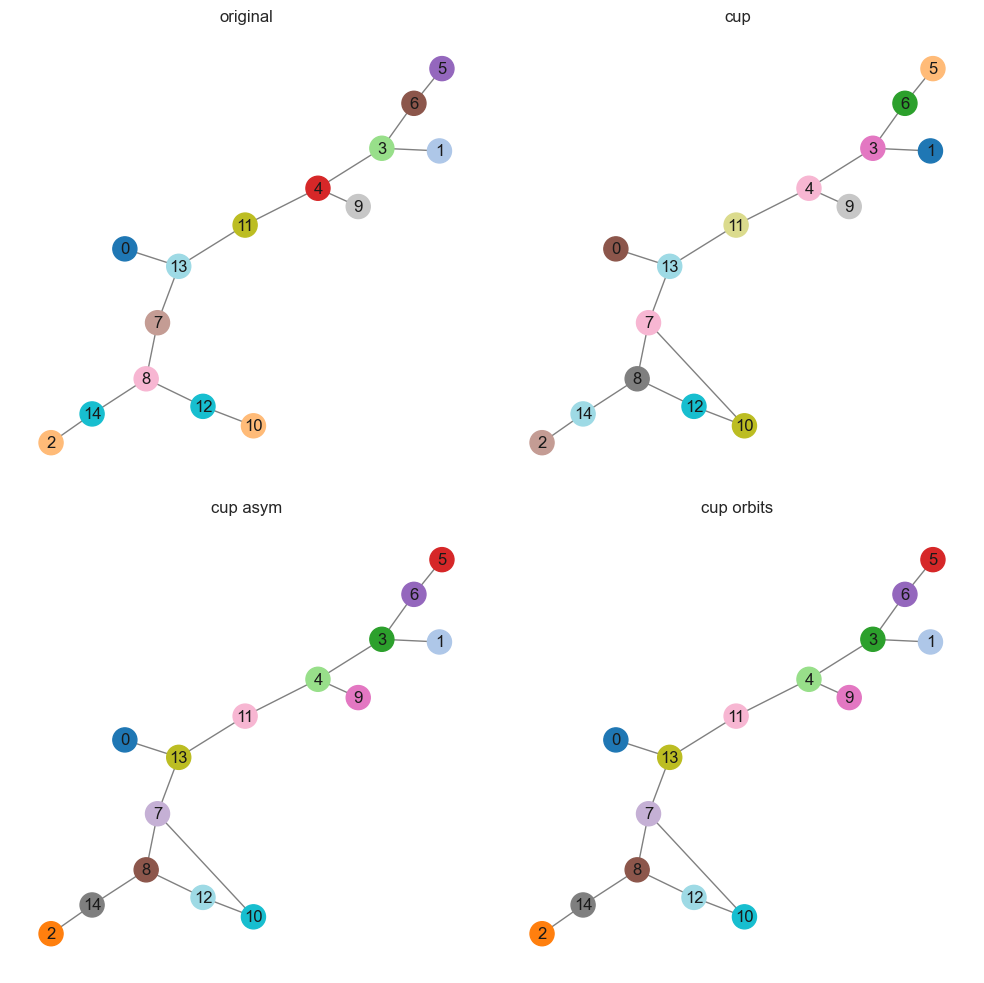

In [ ]:
# WYGENEROWAĆ PRZYKŁAD

pos = nx.spring_layout(G1, seed=42)

fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.ravel()

color_sets = [c, *c_list]
titles = ['original', 'cup', 'cup asym', 'cup orbits']

# use a bright qualitative colormap (more distinct than tab10)
cmap = plt.cm.get_cmap('tab20', 20)  # up to 20 distinct colors
i = 0
for ax, cs, title in zip(axes, color_sets, titles):
    if i == 0: 
        G = G1 
    else: 
        G = G2
    i+= 1
    color_map = [cs.loc[node] for node in G.nodes()]
    nx.draw(
        G, pos,
        with_labels=True,
        node_color=color_map,
        cmap=cmap,
        edge_color='gray',
        ax=ax
    )
    ax.set_title(title)

plt.tight_layout()
plt.show()
